In [78]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score

plt.rcParams.update({
    "font.size": 10,        # default text
    "axes.titlesize": 12,   # title
    "axes.labelsize": 12,   # axis labels
    "xtick.labelsize": 10,  # x tick labels
    "ytick.labelsize": 10,  # y tick labels
    "legend.fontsize": 10
})

result_dir = "/mnt/oss_nanhu100TB/default/zjq/results/SpecFun/result/"

In [79]:
dataset = "desi-sv1" #desi-sv1
# mods = ["sp", "im", "ph", "im+ph", "sp+im", "sp+ph", "sp+im+ph"][:1]
mods = ["ph", "im+ph", "sp+im+ph"]
targets = ["type"]

In [83]:
        metrics_dict[mod]["cut"].append(cut)
        metrics_dict[mod]["acc"].append(acc)
        metrics_dict[mod]["qso_recall"].append(qso_recall)
        metrics_dict[mod]["n_qso"].append(n_qso_cut)

/tmp/ipykernel_2207534/1927956236.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


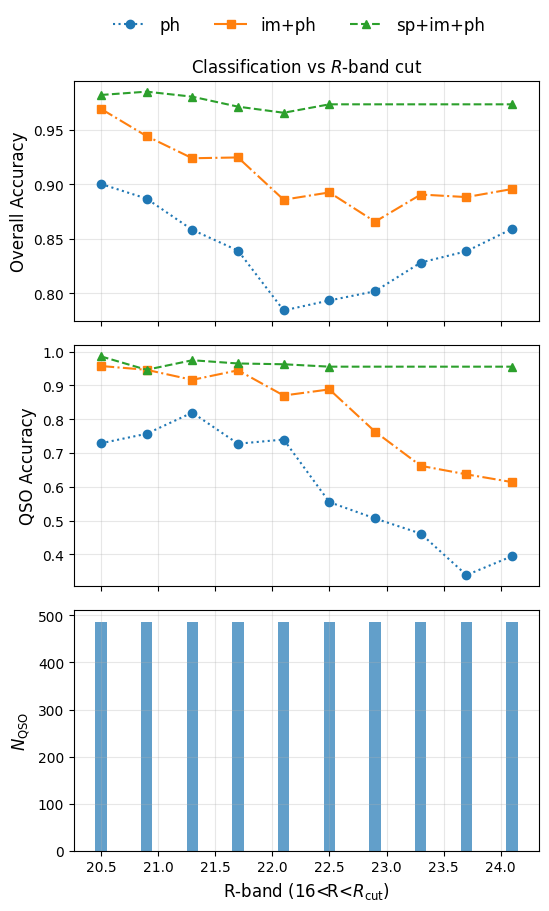

In [84]:
fig = plt.figure(figsize=(6, 10))
gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.1)

markers = ['o', 's', '^', 'D', 'v']          # circle, square, triangle, diamond, triangle-down
linestyles = [':', '-.', '--', '-.', (0, (1, 1))]   # solid, dashed, dash‑dot, dotted, loosely dashed

# ---- overall accuracy ----
ax0 = fig.add_subplot(gs[0, 0])
for i, mod in enumerate(mods):
    ax0.plot(
        metrics_dict[mod]["cut"],
        metrics_dict[mod]["acc"],
        marker=markers[i],
        linestyle=linestyles[i],
        label=mod
    )
ax0.set_title("Classification vs $R$-band cut")
ax0.set_ylabel("Overall Accuracy")
ax0.grid(alpha=0.3)
ax0.tick_params(labelbottom=False)

# ---- QSO recall ----
ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)
for i, mod in enumerate(mods):
    ax1.plot(
        metrics_dict[mod]["cut"],
        metrics_dict[mod]["qso_recall"],
        marker=markers[i],
        linestyle=linestyles[i]
    )
ax1.set_ylabel("QSO Accuracy")
ax1.grid(alpha=0.3)
ax1.tick_params(labelbottom=False)

# ---- number of QSOs ----
ax2 = fig.add_subplot(gs[2, 0], sharex=ax0)
ax2.bar(
    metrics_dict[mods[0]]["cut"],
    metrics_dict[mods[0]]["n_qso"],
    color="C0",
    width=0.1,
    alpha=0.7
)
ax2.set_ylabel(r"$N_{\rm QSO}$")
ax2.set_xlabel(r"R-band (16<R<$R_{\text{cut}}$)")
ax2.grid(alpha=0.3)
handles, labels = ax0.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96),
    ncol=len(mods),
    frameon=False,
    fontsize=12
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()